In [148]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import metrics
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
import itertools
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
import statsmodels.api as sm

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import matplotlib.ticker as mtick
import calendar

In [152]:
df = pd.read_excel('backup.xlsx')

Distribution of Occupancy Rate.

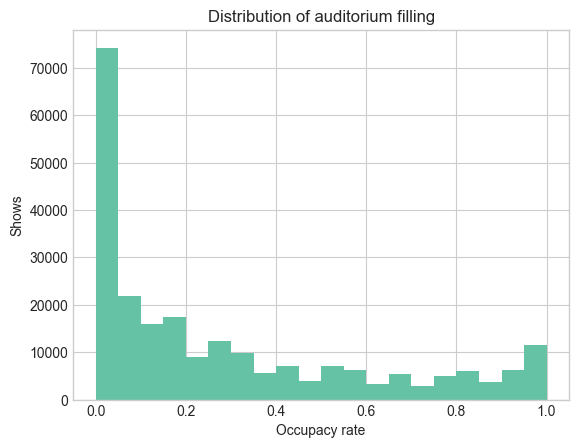

In [153]:
df['occupacyRate'].hist(bins=20)
plt.xlabel('Occupacy rate')
plt.ylabel('Shows')
plt.title('Distribution of auditorium filling')
plt.show()

Do projection formats differ in demand?
Tickets sold: 2D vs 3D.

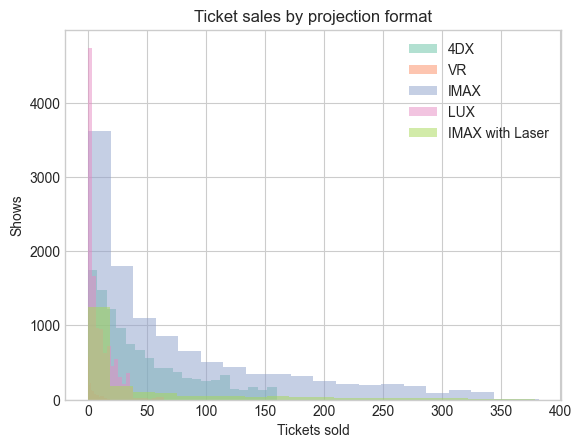

In [156]:
# plt.hist(df[df['Technology'].str.contains('Cinetech')]['quantitySold'], bins=20, alpha=.5, label='Cinetech')
plt.hist(df[df['Technology'].str.contains('4DX')]['quantitySold'], bins=20, alpha=.5, label='4DX')
plt.hist(df[df['Technology'].str.contains('VR')]['quantitySold'], bins=20, alpha=.5, label='VR')
plt.hist(df[df['Technology'].str.contains('IMAX')]['quantitySold'], bins=20, alpha=.5, label='IMAX')
plt.hist(df[df['Technology'].str.contains('LUX')]['quantitySold'], bins=20, alpha=.5, label='LUX')
plt.hist(df[df['Technology'].str.contains('IMAX with Laser')]['quantitySold'], bins=20, alpha=.5, label='IMAX with Laser')

plt.xlabel('Tickets sold')
plt.ylabel('Shows')
plt.legend()
plt.title('Ticket sales by projection format')
plt.show()

Which cities generate most profit?

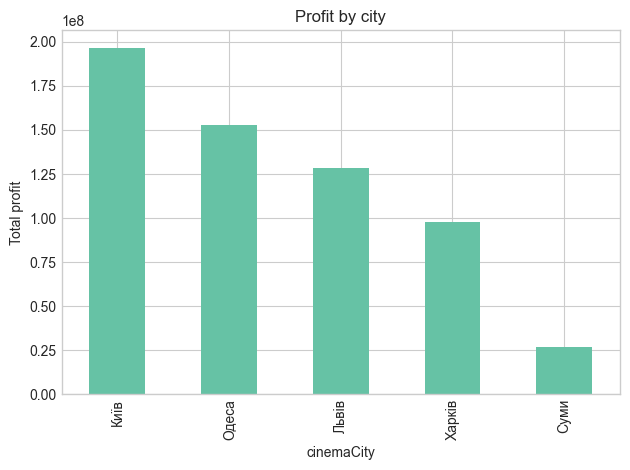

In [157]:
city_profit = df.groupby('cinemaCity')['profitEarned'].sum().sort_values(ascending=False)
city_profit.plot(kind='bar')
plt.ylabel('Total profit')
plt.title('Profit by city')
plt.tight_layout()
plt.show()

Does a premiere boost attendance?
Average tickets per show.

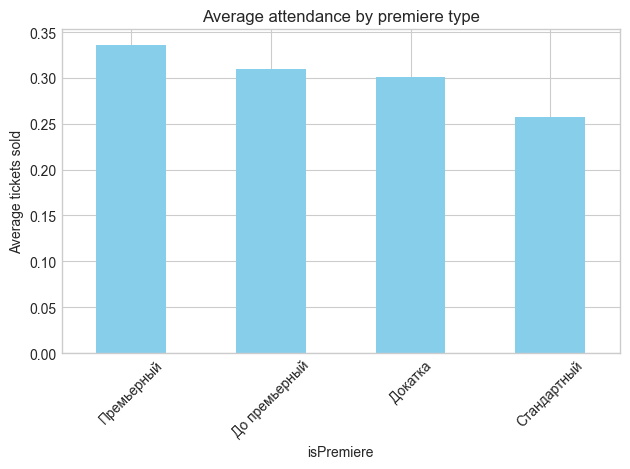

In [158]:
premiere_avg = (
    df.groupby('isPremiere')['occupacyRate']
      .mean()
      .sort_values(ascending=False)
)

premiere_avg.plot(kind='bar', color='skyblue')
plt.ylabel('Average tickets sold')
plt.title('Average attendance by premiere type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

How strong is the link between auditorium filling and profit? Scatter + trend-line.

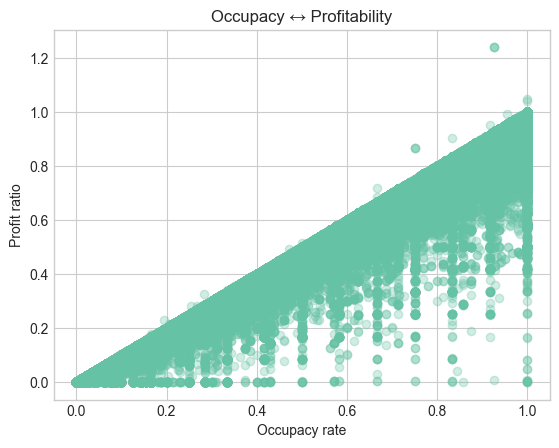

In [160]:
sns.regplot(x='occupacyRate', y='profitRatio', data=df, scatter_kws={'alpha':0.3})
plt.xlabel('Occupacy rate')
plt.ylabel('Profit ratio')
plt.title('Occupacy ↔ Profitability')
plt.show()

Hourly demand pattern – heat-map of tickets sold by hour × weekday.

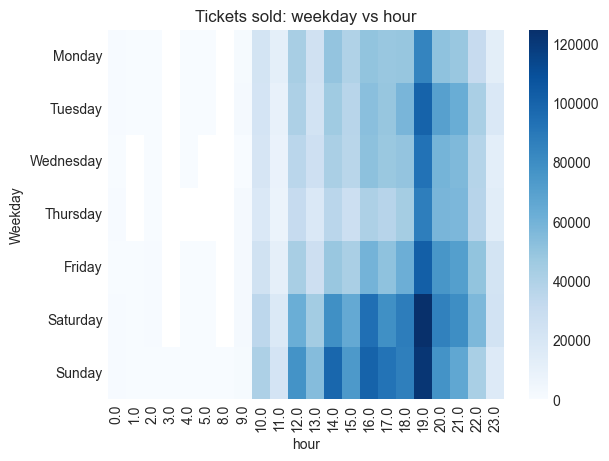

In [161]:
pivot = (df.pivot_table(values='quantitySold', index=df['week'], columns='hour', aggfunc='sum') .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])) 
sns.heatmap(pivot, cmap='Blues')
plt.title('Tickets sold: weekday vs hour')
plt.ylabel('Weekday')
plt.show()

Weekly trend of total attendance across three years.

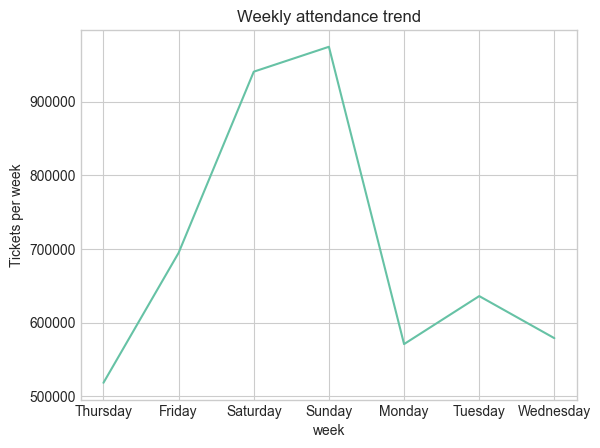

In [162]:
weekly = (df.groupby('week')['quantitySold']
            .sum()
            .reindex(['Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday'])) 
weekly.plot()
plt.ylabel('Tickets per week')
plt.title('Weekly attendance trend')
plt.show()

Correlation matrix (numerical fields only) for a quick multicollinearity check.

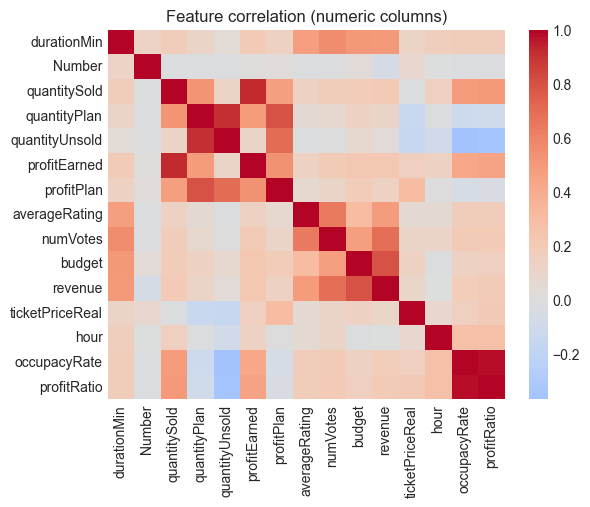

In [163]:
num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature correlation (numeric columns)')
plt.show()

Seat-type mix – stacked bars of sold tickets by seatType.

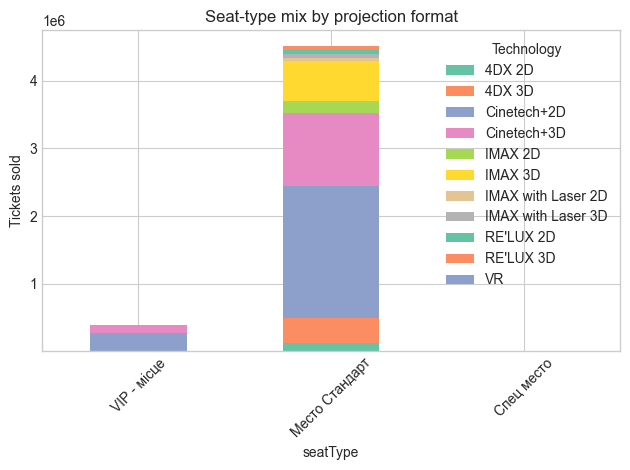

In [164]:
seat_sales = df.groupby(['seatType','Technology'])['quantitySold'].sum().unstack(fill_value=0)
seat_sales.plot(kind='bar', stacked=True)
plt.ylabel('Tickets sold')
plt.title('Seat-type mix by projection format')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [165]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

In [166]:
# Load the data
# df = pd.read_csv('cinema_data.csv')  # Replace with your actual file path

# 1. Overall Statistics and Distribution Analysis
def analyze_overall_statistics(df):
    # Basic statistics for key metrics
    numeric_cols = ['quantitySold', 'quantityPlan', 'profitEarned', 'profitPlan', 'occupacyRate', 'profitRatio', 'ticketPriceReal', 'averageRating']
    stats = df[numeric_cols].describe().T
    
    # Create figure for distribution of key metrics
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot distributions
    sns.histplot(df['occupacyRate'], kde=True, ax=axes[0, 0])
    axes[0, 0].set_title('Distribution of Occupancy Rate')
    axes[0, 0].set_xlabel('Occupancy Rate')
    axes[0, 0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    sns.histplot(df['profitRatio'], kde=True, ax=axes[0, 1])
    axes[0, 1].set_title('Distribution of Profit Ratio')
    axes[0, 1].set_xlabel('Profit Ratio')
    axes[0, 1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    sns.histplot(df['ticketPriceReal'].dropna(), kde=True, ax=axes[1, 0])
    axes[1, 0].set_title('Distribution of Actual Ticket Prices')
    axes[1, 0].set_xlabel('Ticket Price')
    
    sns.histplot(df['averageRating'], kde=True, ax=axes[1, 1])
    axes[1, 1].set_title('Distribution of IMDb Ratings')
    axes[1, 1].set_xlabel('Rating')
    
    plt.tight_layout()
    plt.savefig('key_metrics_distribution.png', dpi=300)
    
    return stats

In [167]:
# 2. Temporal Analysis
def analyze_temporal_patterns(df):
    # Convert Date to datetime
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month
    df['Year'] = df['Date'].dt.year
    
    # Attendance and profit by day of week
    weekly_data = df.groupby('week').agg({
        'occupacyRate': 'mean',
        'profitRatio': 'mean',
        'quantitySold': 'sum',
        'profitEarned': 'sum'
    }).reset_index()
    
    # Order days of week properly
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    weekly_data['week'] = pd.Categorical(weekly_data['week'], categories=day_order, ordered=True)
    weekly_data = weekly_data.sort_values('week')
    
    # Time period analysis
    period_data = df.groupby('period').agg({
        'occupacyRate': 'mean',
        'profitRatio': 'mean',
        'quantitySold': 'sum',
        'profitEarned': 'sum'
    }).reset_index()
    
    # Proper order for time periods
    period_order = ['morning', 'daytime', 'evening', 'night']
    period_data['period'] = pd.Categorical(period_data['period'], categories=period_order, ordered=True)
    period_data = period_data.sort_values('period')
    
    # Monthly trends
    monthly_data = df.groupby('Month').agg({
        'occupacyRate': 'mean',
        'profitRatio': 'mean',
        'quantitySold': 'sum',
        'profitEarned': 'sum'
    }).reset_index()
    
    # Add month names
    monthly_data['Month_Name'] = monthly_data['Month'].apply(lambda x: calendar.month_name[x])
    
    # Create plots
    fig, axes = plt.subplots(3, 1, figsize=(14, 18))
    
    # Weekly patterns plot
    sns.barplot(x='week', y='occupacyRate', data=weekly_data, ax=axes[0])
    axes[0].set_title('Average Occupancy Rate by Day of Week')
    axes[0].set_xlabel('Day of Week')
    axes[0].set_ylabel('Occupancy Rate')
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Time period plot
    sns.barplot(x='period', y='occupacyRate', data=period_data, ax=axes[1])
    axes[1].set_title('Average Occupancy Rate by Time Period')
    axes[1].set_xlabel('Time Period')
    axes[1].set_ylabel('Occupancy Rate')
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Monthly trends plot
    sns.lineplot(x='Month', y='occupacyRate', data=monthly_data, marker='o', ax=axes[2])
    axes[2].set_title('Monthly Trend in Occupancy Rate')
    axes[2].set_xlabel('Month')
    axes[2].set_ylabel('Occupancy Rate')
    axes[2].set_xticks(monthly_data['Month'])
    axes[2].set_xticklabels(monthly_data['Month_Name'])
    axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    plt.tight_layout()
    plt.savefig('temporal_patterns.png', dpi=300)
    
    return weekly_data, period_data, monthly_data


In [168]:
# 3. Content Analysis
def analyze_film_characteristics(df):
    # Extract main genre for each film
    df['main_genre'] = df['genres'].apply(lambda x: x.split(',')[0] if isinstance(x, str) else 'Unknown')
    
    # Genre performance
    genre_performance = df.groupby('main_genre').agg({
        'occupacyRate': 'mean',
        'profitRatio': 'mean',
        'quantitySold': 'sum',
        'Film': pd.Series.nunique
    }).sort_values(by='occupacyRate', ascending=False).reset_index()
    genre_performance = genre_performance.rename(columns={'Film': 'Number_of_Films'})
    
    # MPAA Rating performance
    mpaa_performance = df.groupby('mpaaRating').agg({
        'occupacyRate': 'mean',
        'profitRatio': 'mean',
        'quantitySold': 'sum',
        'Film': pd.Series.nunique
    }).sort_values(by='occupacyRate', ascending=False).reset_index()
    mpaa_performance = mpaa_performance.rename(columns={'Film': 'Number_of_Films'})
    
    # Language performance
    language_performance = df.groupby('originalLanguage').agg({
        'occupacyRate': 'mean',
        'profitRatio': 'mean',
        'quantitySold': 'sum',
        'Film': pd.Series.nunique
    }).sort_values(by='quantitySold', ascending=False).head(10).reset_index()
    language_performance = language_performance.rename(columns={'Film': 'Number_of_Films'})
    
    # Create plots
    fig, axes = plt.subplots(3, 1, figsize=(14, 18))
    
    # Genre performance plot (top 10)
    top_genres = genre_performance.head(10)
    sns.barplot(x='occupacyRate', y='main_genre', data=top_genres, ax=axes[0])
    axes[0].set_title('Top 10 Genres by Occupancy Rate')
    axes[0].set_xlabel('Occupancy Rate')
    axes[0].set_ylabel('Genre')
    axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # MPAA Rating performance plot
    sns.barplot(x='occupacyRate', y='mpaaRating', data=mpaa_performance, ax=axes[1])
    axes[1].set_title('Occupancy Rate by MPAA Rating')
    axes[1].set_xlabel('Occupancy Rate')
    axes[1].set_ylabel('MPAA Rating')
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Language performance plot (top 10)
    sns.barplot(x='occupacyRate', y='originalLanguage', data=language_performance, ax=axes[2])
    axes[2].set_title('Occupancy Rate by Original Language (Top 10)')
    axes[2].set_xlabel('Occupancy Rate')
    axes[2].set_ylabel('Original Language')
    axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    plt.tight_layout()
    plt.savefig('content_analysis.png', dpi=300)
    
    return genre_performance, mpaa_performance, language_performance


In [169]:

# 4. Venue Analysis
def analyze_venues(df):
    # Cinema performance
    cinema_performance = df.groupby('Cinema').agg({
        'occupacyRate': 'mean',
        'profitRatio': 'mean',
        'quantitySold': 'sum',
        'Film': pd.Series.nunique
    }).sort_values(by='quantitySold', ascending=False).reset_index()
    cinema_performance = cinema_performance.rename(columns={'Film': 'Number_of_Films'})
    
    # City performance
    city_performance = df.groupby(['cinemaCity', 'populationCity']).agg({
        'occupacyRate': 'mean',
        'profitRatio': 'mean',
        'quantitySold': 'sum',
        'Cinema': pd.Series.nunique
    }).sort_values(by='quantitySold', ascending=False).reset_index()
    city_performance = city_performance.rename(columns={'Cinema': 'Number_of_Cinemas'})
    
    # Technology performance
    tech_performance = df.groupby('Technology').agg({
        'occupacyRate': 'mean',
        'profitRatio': 'mean',
        'quantitySold': 'sum',
        'ticketPriceReal': 'mean'
    }).sort_values(by='occupacyRate', ascending=False).reset_index()
    
    # Create plots
    fig, axes = plt.subplots(3, 1, figsize=(14, 18))
    
    # Cinema performance plot (top 10)
    top_cinemas = cinema_performance.head(10)
    sns.barplot(x='occupacyRate', y='Cinema', data=top_cinemas, ax=axes[0])
    axes[0].set_title('Top 10 Cinemas by Occupancy Rate')
    axes[0].set_xlabel('Occupancy Rate')
    axes[0].set_ylabel('Cinema')
    axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # City performance plot (top 10)
    top_cities = city_performance.head(10)
    sns.barplot(x='occupacyRate', y='cinemaCity', data=top_cities, ax=axes[1])
    axes[1].set_title('Top 10 Cities by Occupancy Rate')
    axes[1].set_xlabel('Occupancy Rate')
    axes[1].set_ylabel('City')
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Technology performance plot
    sns.barplot(x='occupacyRate', y='Technology', data=tech_performance, ax=axes[2])
    axes[2].set_title('Occupancy Rate by Screening Technology')
    axes[2].set_xlabel('Occupancy Rate')
    axes[2].set_ylabel('Technology')
    axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    plt.tight_layout()
    plt.savefig('venue_analysis.png', dpi=300)
    
    return cinema_performance, city_performance, tech_performance


In [170]:
# 5. Correlation Analysis
def analyze_correlations(df):
    # Select relevant numeric columns
    corr_columns = ['quantitySold', 'quantityPlan', 'profitEarned', 'profitPlan', 
                   'occupacyRate', 'profitRatio', 'ticketPriceReal', 'averageRating', 
                   'numVotes', 'budget', 'revenue', 'durationMin']
    
    # Calculate correlation matrix
    correlation_matrix = df[corr_columns].corr()
    
    # Create correlation heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix of Key Metrics')
    plt.tight_layout()
    plt.savefig('correlation_analysis.png', dpi=300)
    
    return correlation_matrix


In [171]:
def run_all_analyses(df):
    print("Starting Exploratory Data Analysis...")
    
    print("\n1. Overall Statistics and Distribution Analysis")
    stats = analyze_overall_statistics(df)
    print(stats)
    
    print("\n2. Temporal Analysis")
    weekly_data, period_data, monthly_data = analyze_temporal_patterns(df)
    print("Weekly Data Summary:")
    print(weekly_data)
    print("\nPeriod Data Summary:")
    print(period_data)
    print("\nMonthly Data Summary:")
    print(monthly_data)
    
    print("\n3. Content Analysis")
    genre_performance, mpaa_performance, language_performance = analyze_film_characteristics(df)
    print("Genre Performance Summary:")
    print(genre_performance.head(10))
    print("\nMPAA Rating Performance Summary:")
    print(mpaa_performance)
    print("\nLanguage Performance Summary:")
    print(language_performance)
    
    print("\n4. Venue Analysis")
    cinema_performance, city_performance, tech_performance = analyze_venues(df)
    print("Cinema Performance Summary:")
    print(cinema_performance.head(10))
    print("\nCity Performance Summary:")
    print(city_performance.head(10))
    print("\nTechnology Performance Summary:")
    print(tech_performance)
    
    print("\n5. Correlation Analysis")
    correlation_matrix = analyze_correlations(df)
    print("Correlation Matrix:")
    print(correlation_matrix)
    
    print("\nEDA completed successfully. All visualizations saved as PNG files.")

# To execute all the analyses:
# run_all_analyses(df)

Starting Exploratory Data Analysis...

1. Overall Statistics and Distribution Analysis
                    count          mean           std  min          25%  \
quantitySold     234266.0     20.973103     36.044782  0.0     2.000000   
quantityPlan     234266.0     84.094474     85.681635  1.0    12.000000   
profitEarned     234266.0   2572.607499   5312.650848  0.0   136.000000   
profitPlan       234266.0  10683.388272  14866.253164  2.0  2015.000000   
occupacyRate     234266.0      0.284466      0.311886  0.0     0.019048   
profitRatio      234266.0      0.254612      0.285517  0.0     0.013699   
ticketPriceReal  182590.0    123.957436     74.048805  0.0    84.722339   
averageRating    234266.0      6.503428      0.889948  2.2     6.100000   

                         50%           75%           max  
quantitySold        7.000000     22.750000  3.820000e+02  
quantityPlan       70.000000    120.000000  4.350000e+02  
profitEarned      855.000000   2497.000000  1.813000e+05  
p

/var/folders/bt/_x0h2pb92g55h0wvnfmyf_900000gp/T/ipykernel_29787/2221134954.py:4: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['Date'] = pd.to_datetime(df['Date'])


Weekly Data Summary:
        week  occupacyRate  profitRatio  quantitySold  profitEarned
1     Monday      0.239228     0.212082        570768  7.013135e+07
5    Tuesday      0.253638     0.228489        635914  6.917115e+07
6  Wednesday      0.233840     0.206376        578788  7.000060e+07
4   Thursday      0.227437     0.203064        518234  6.357074e+07
0     Friday      0.287046     0.256040        694641  8.738063e+07
2   Saturday      0.361420     0.326024        940572  1.190336e+08
3     Sunday      0.380770     0.343084        974368  1.233864e+08

Period Data Summary:
  period  occupacyRate  profitRatio  quantitySold  profitEarned
0    NaN      0.380809     0.343586       2490128  3.169982e+08
1    NaN      0.269803     0.239928       2128821  2.515975e+08
2    NaN      0.057717     0.052979          7622  1.307573e+06
3    NaN      0.099647     0.086873        286714  3.277117e+07

Monthly Data Summary:
    Month  occupacyRate  profitRatio  quantitySold  profitEarned Month

Correlation Matrix:
                 quantitySold  quantityPlan  profitEarned  profitPlan  \
quantitySold         1.000000      0.526384      0.922648    0.469949   
quantityPlan         0.526384      1.000000      0.486751    0.797729   
profitEarned         0.922648      0.486751      1.000000    0.532160   
profitPlan           0.469949      0.797729      0.532160    1.000000   
occupacyRate         0.486681     -0.110351      0.427607   -0.048657   
profitRatio          0.494354     -0.097033      0.447957   -0.034754   
ticketPriceReal     -0.012124     -0.137749      0.158399    0.305339   
averageRating        0.148384      0.054836      0.143482    0.071139   
numVotes             0.181990      0.078793      0.196945    0.112694   
budget               0.192198      0.145963      0.227783    0.192133   
revenue              0.207725      0.116608      0.225733    0.144938   
durationMin          0.175095      0.110399      0.200641    0.146313   

                 occupacyRate 

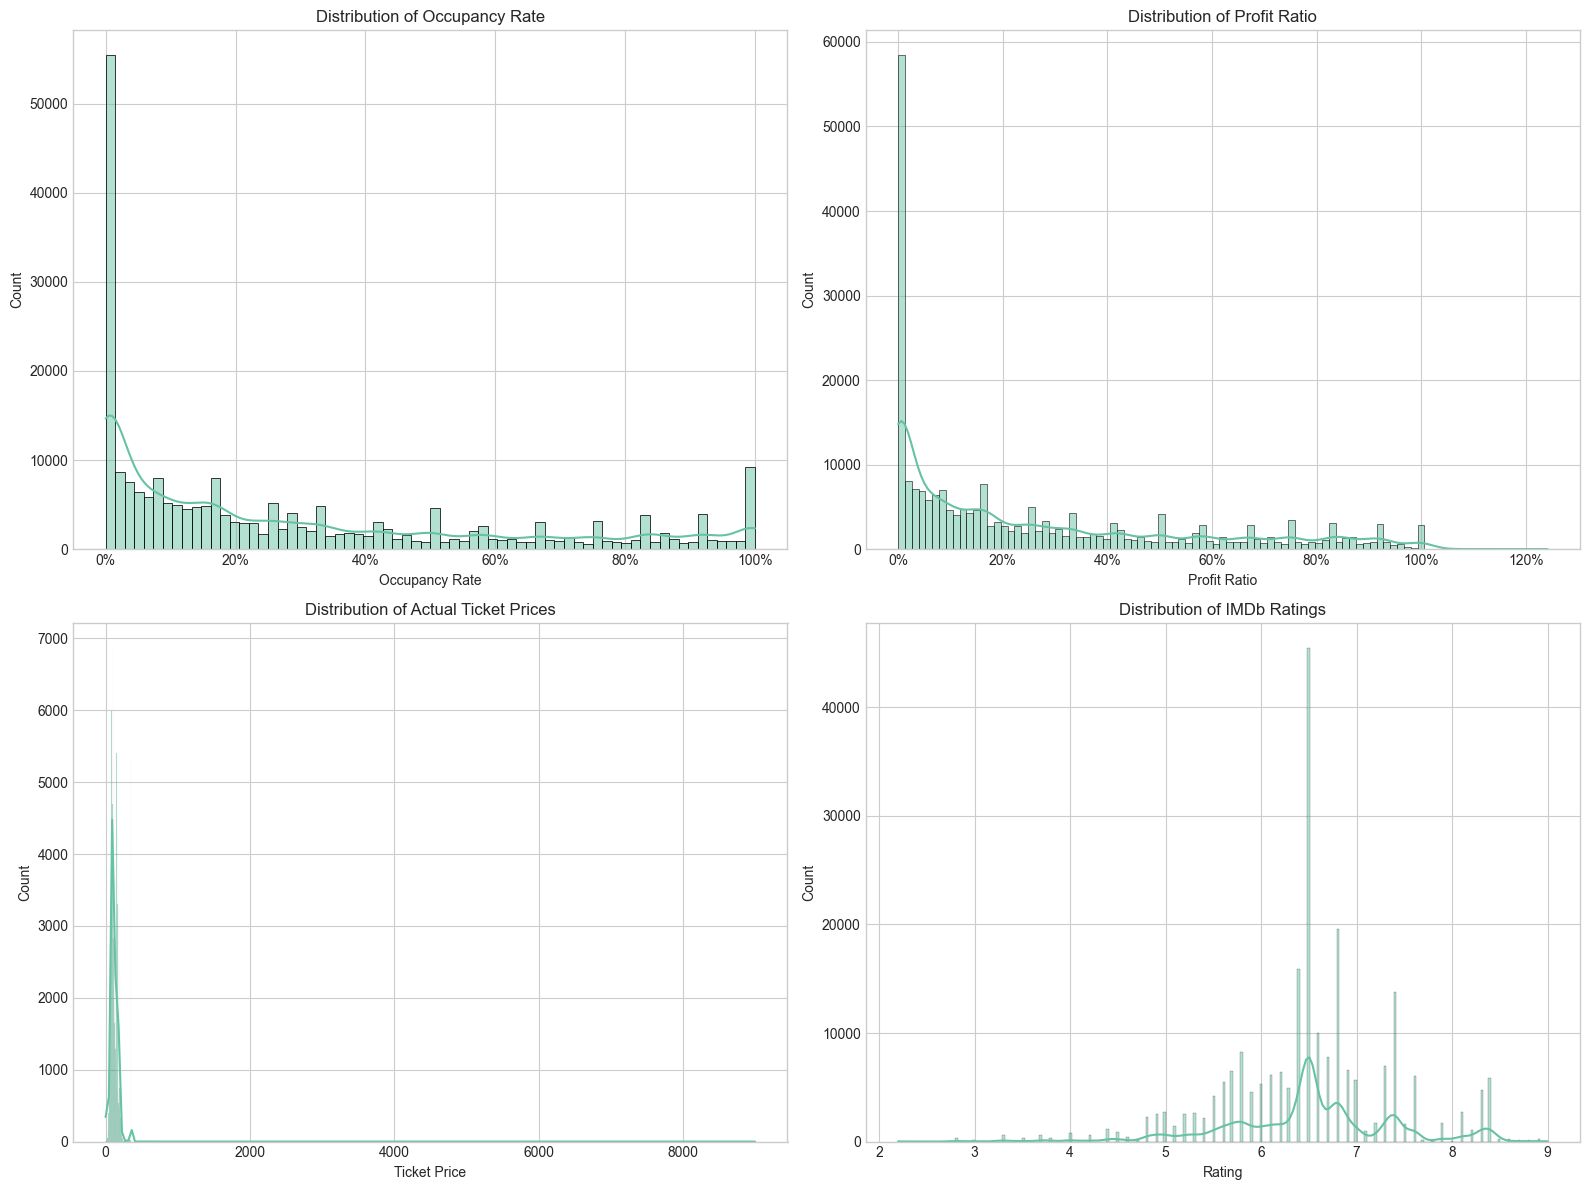

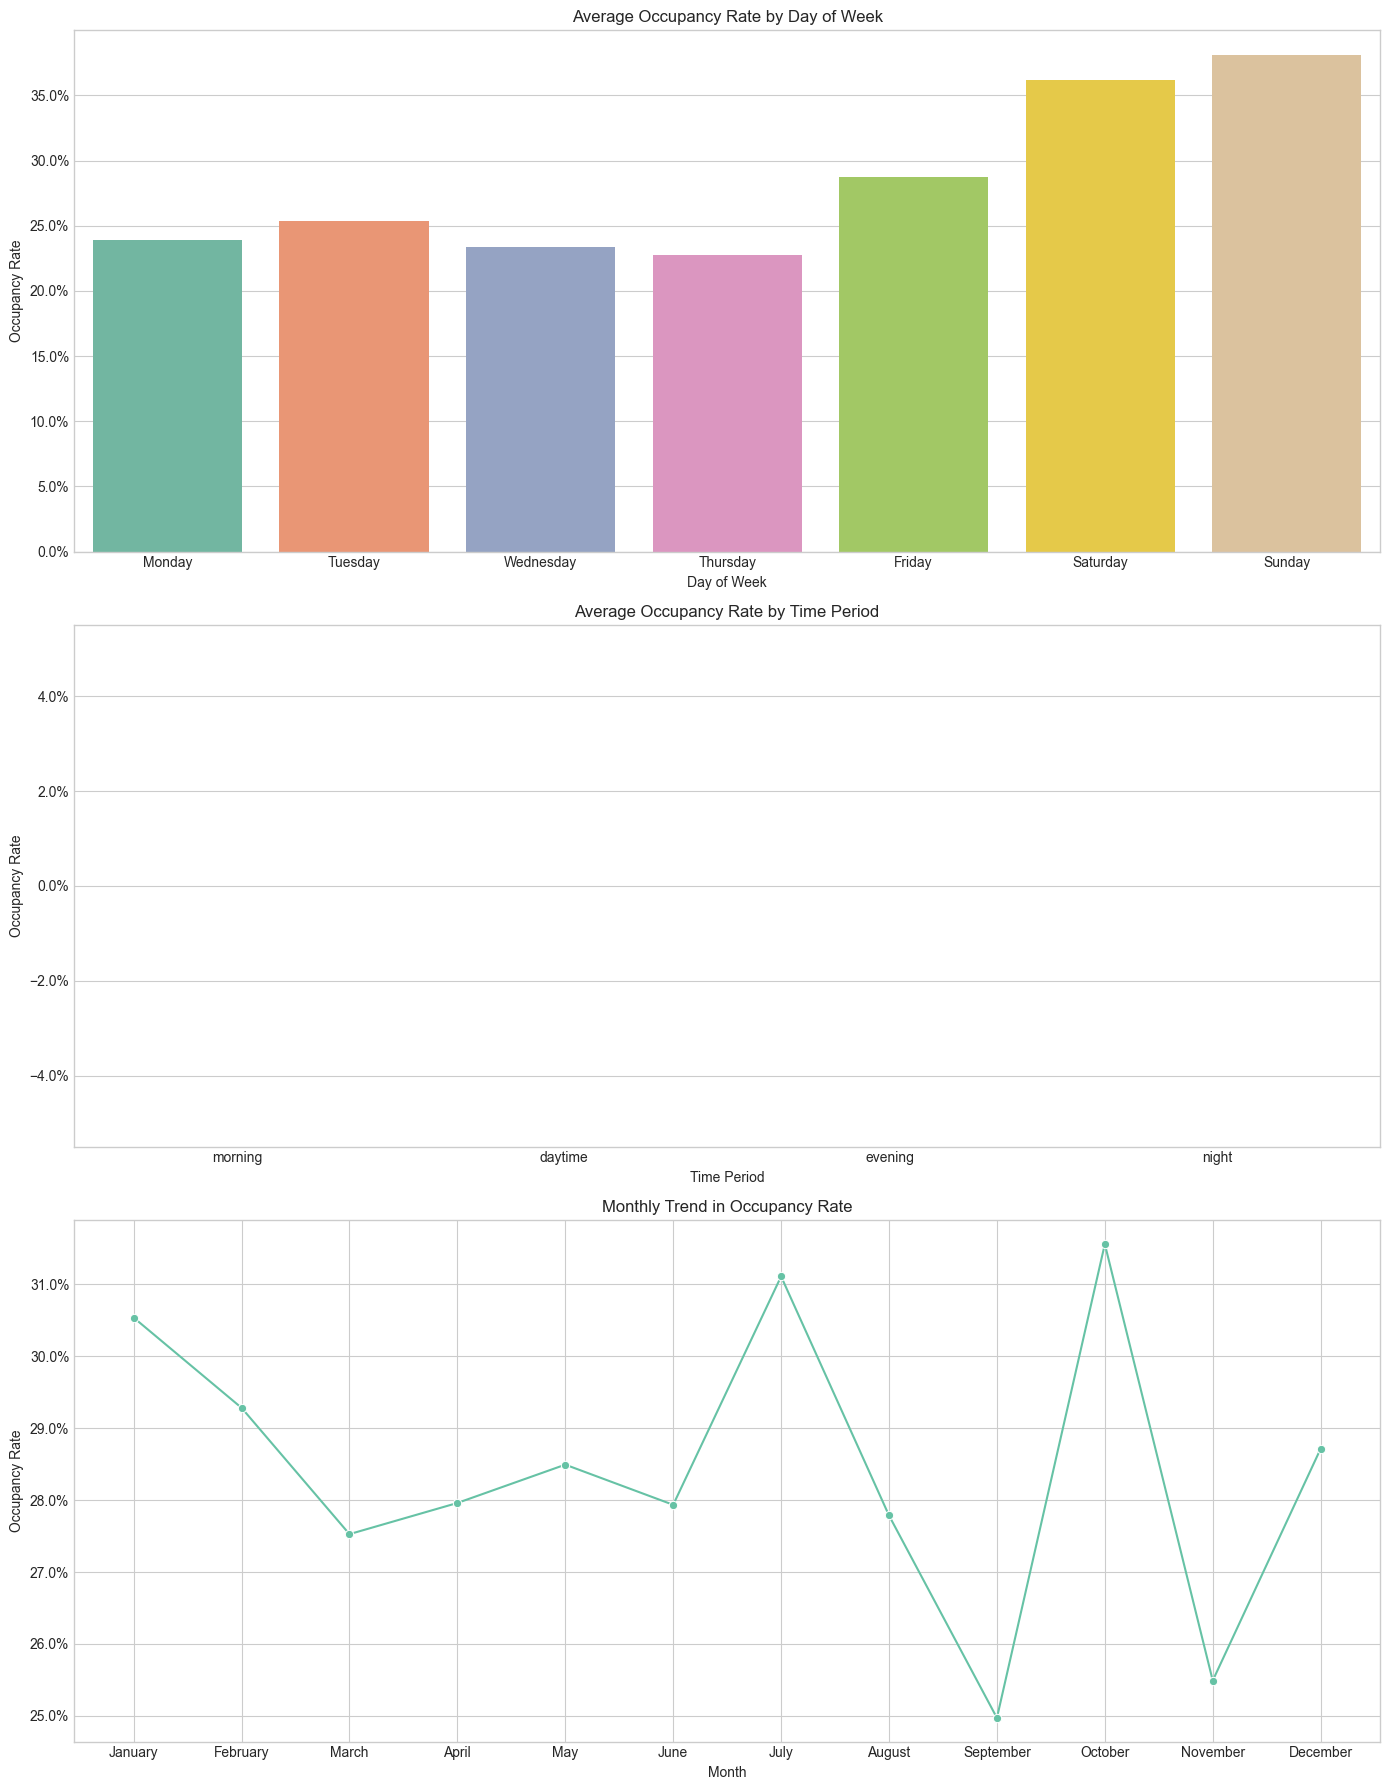

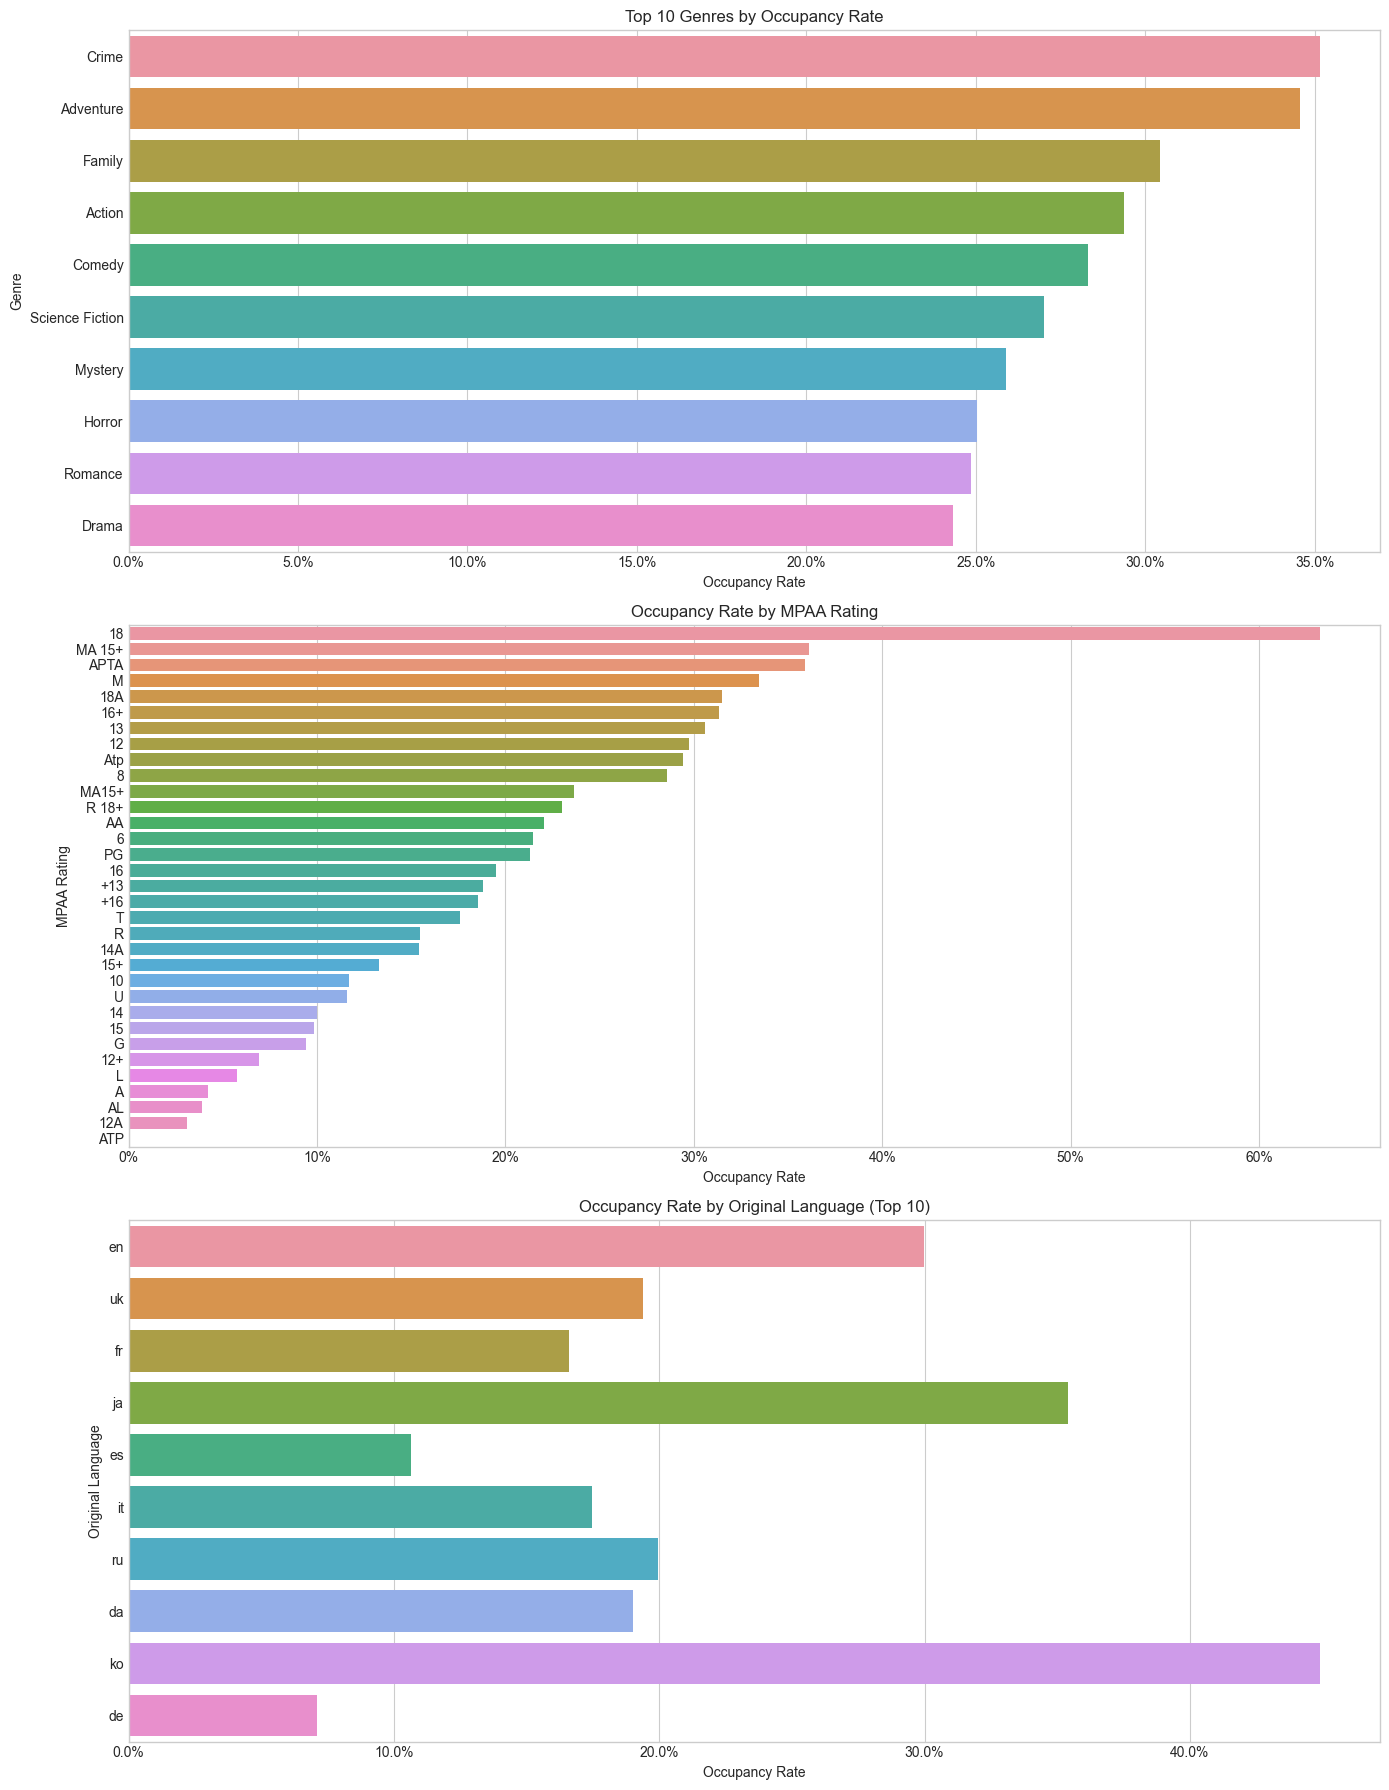

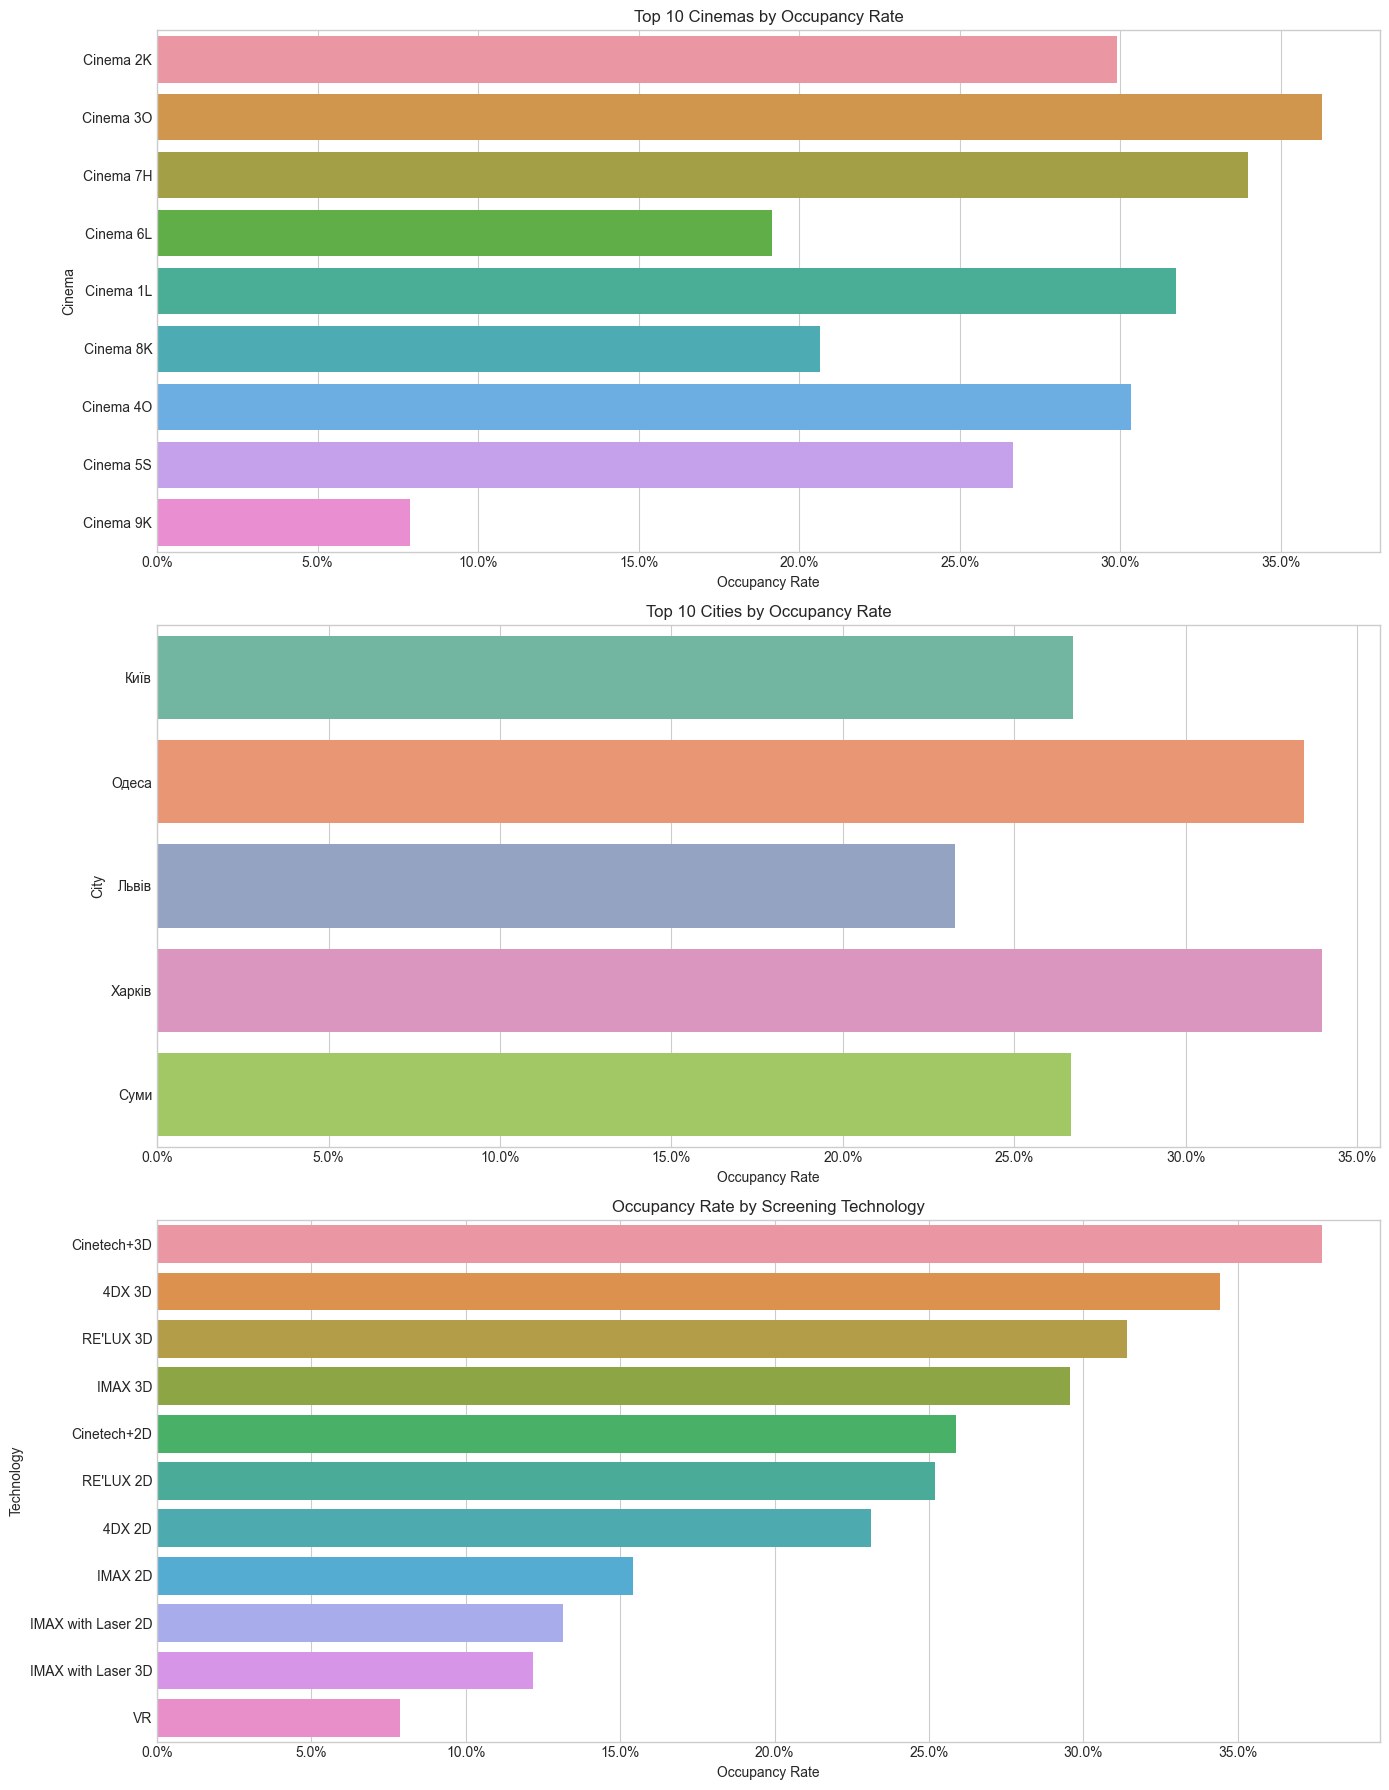

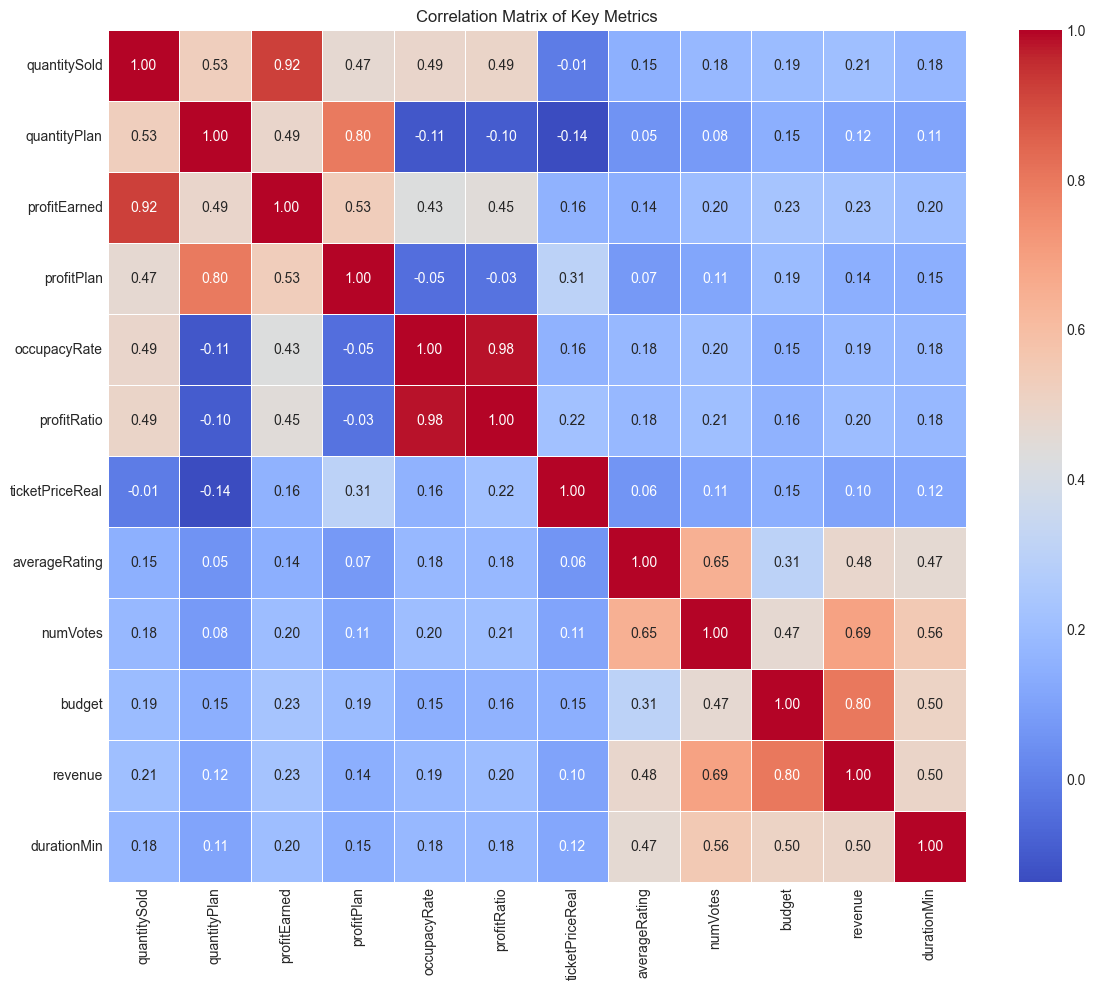

In [172]:
run_all_analyses(df)

# Exploratory Data Analysis

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 234266 entries, 0 to 234266
Data columns (total 38 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Cinema               234266 non-null  object        
 1   Film                 234266 non-null  object        
 2   durationMin          234266 non-null  float64       
 3   Distributor          234266 non-null  object        
 4   Studio               234266 non-null  object        
 5   Auditorium           234266 non-null  object        
 6   Technology           234266 non-null  object        
 7   Number               234266 non-null  float64       
 8   sessionCanceled      234266 non-null  object        
 9   isPremiere           234266 non-null  object        
 10  Date                 234266 non-null  datetime64[ns]
 11  Time                 234266 non-null  object        
 12  seatType             234200 non-null  object        
 13  quantitySold  

Числові - числові 

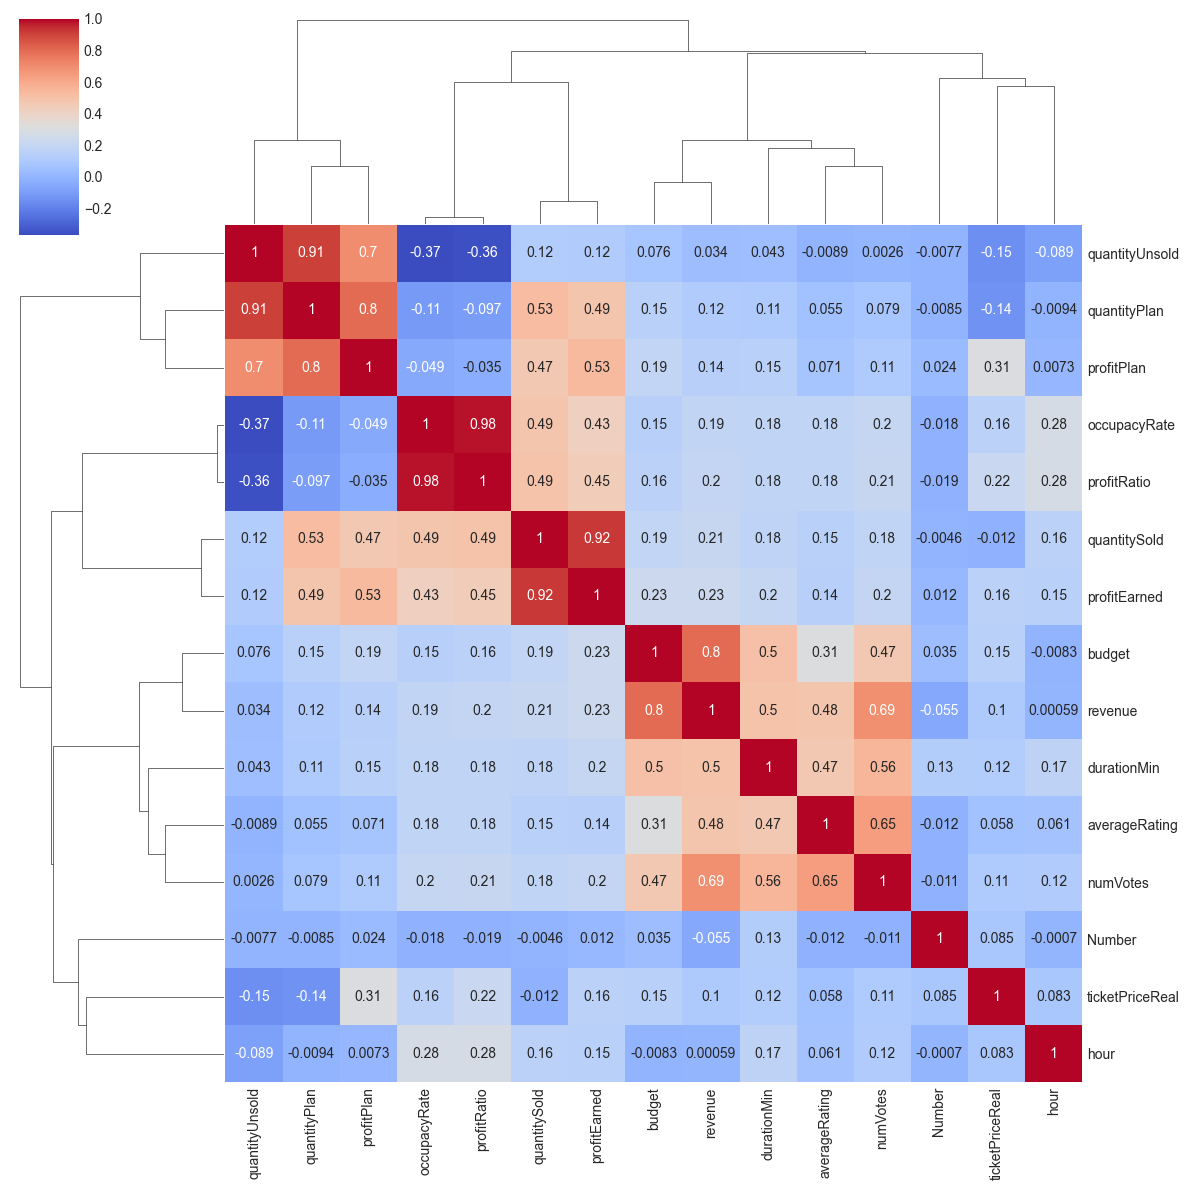

In [174]:
corr = df[num_cols].corr()
sns.clustermap(corr, annot=True, cmap='coolwarm', figsize=(12,12))
plt.show()

KeyboardInterrupt: 

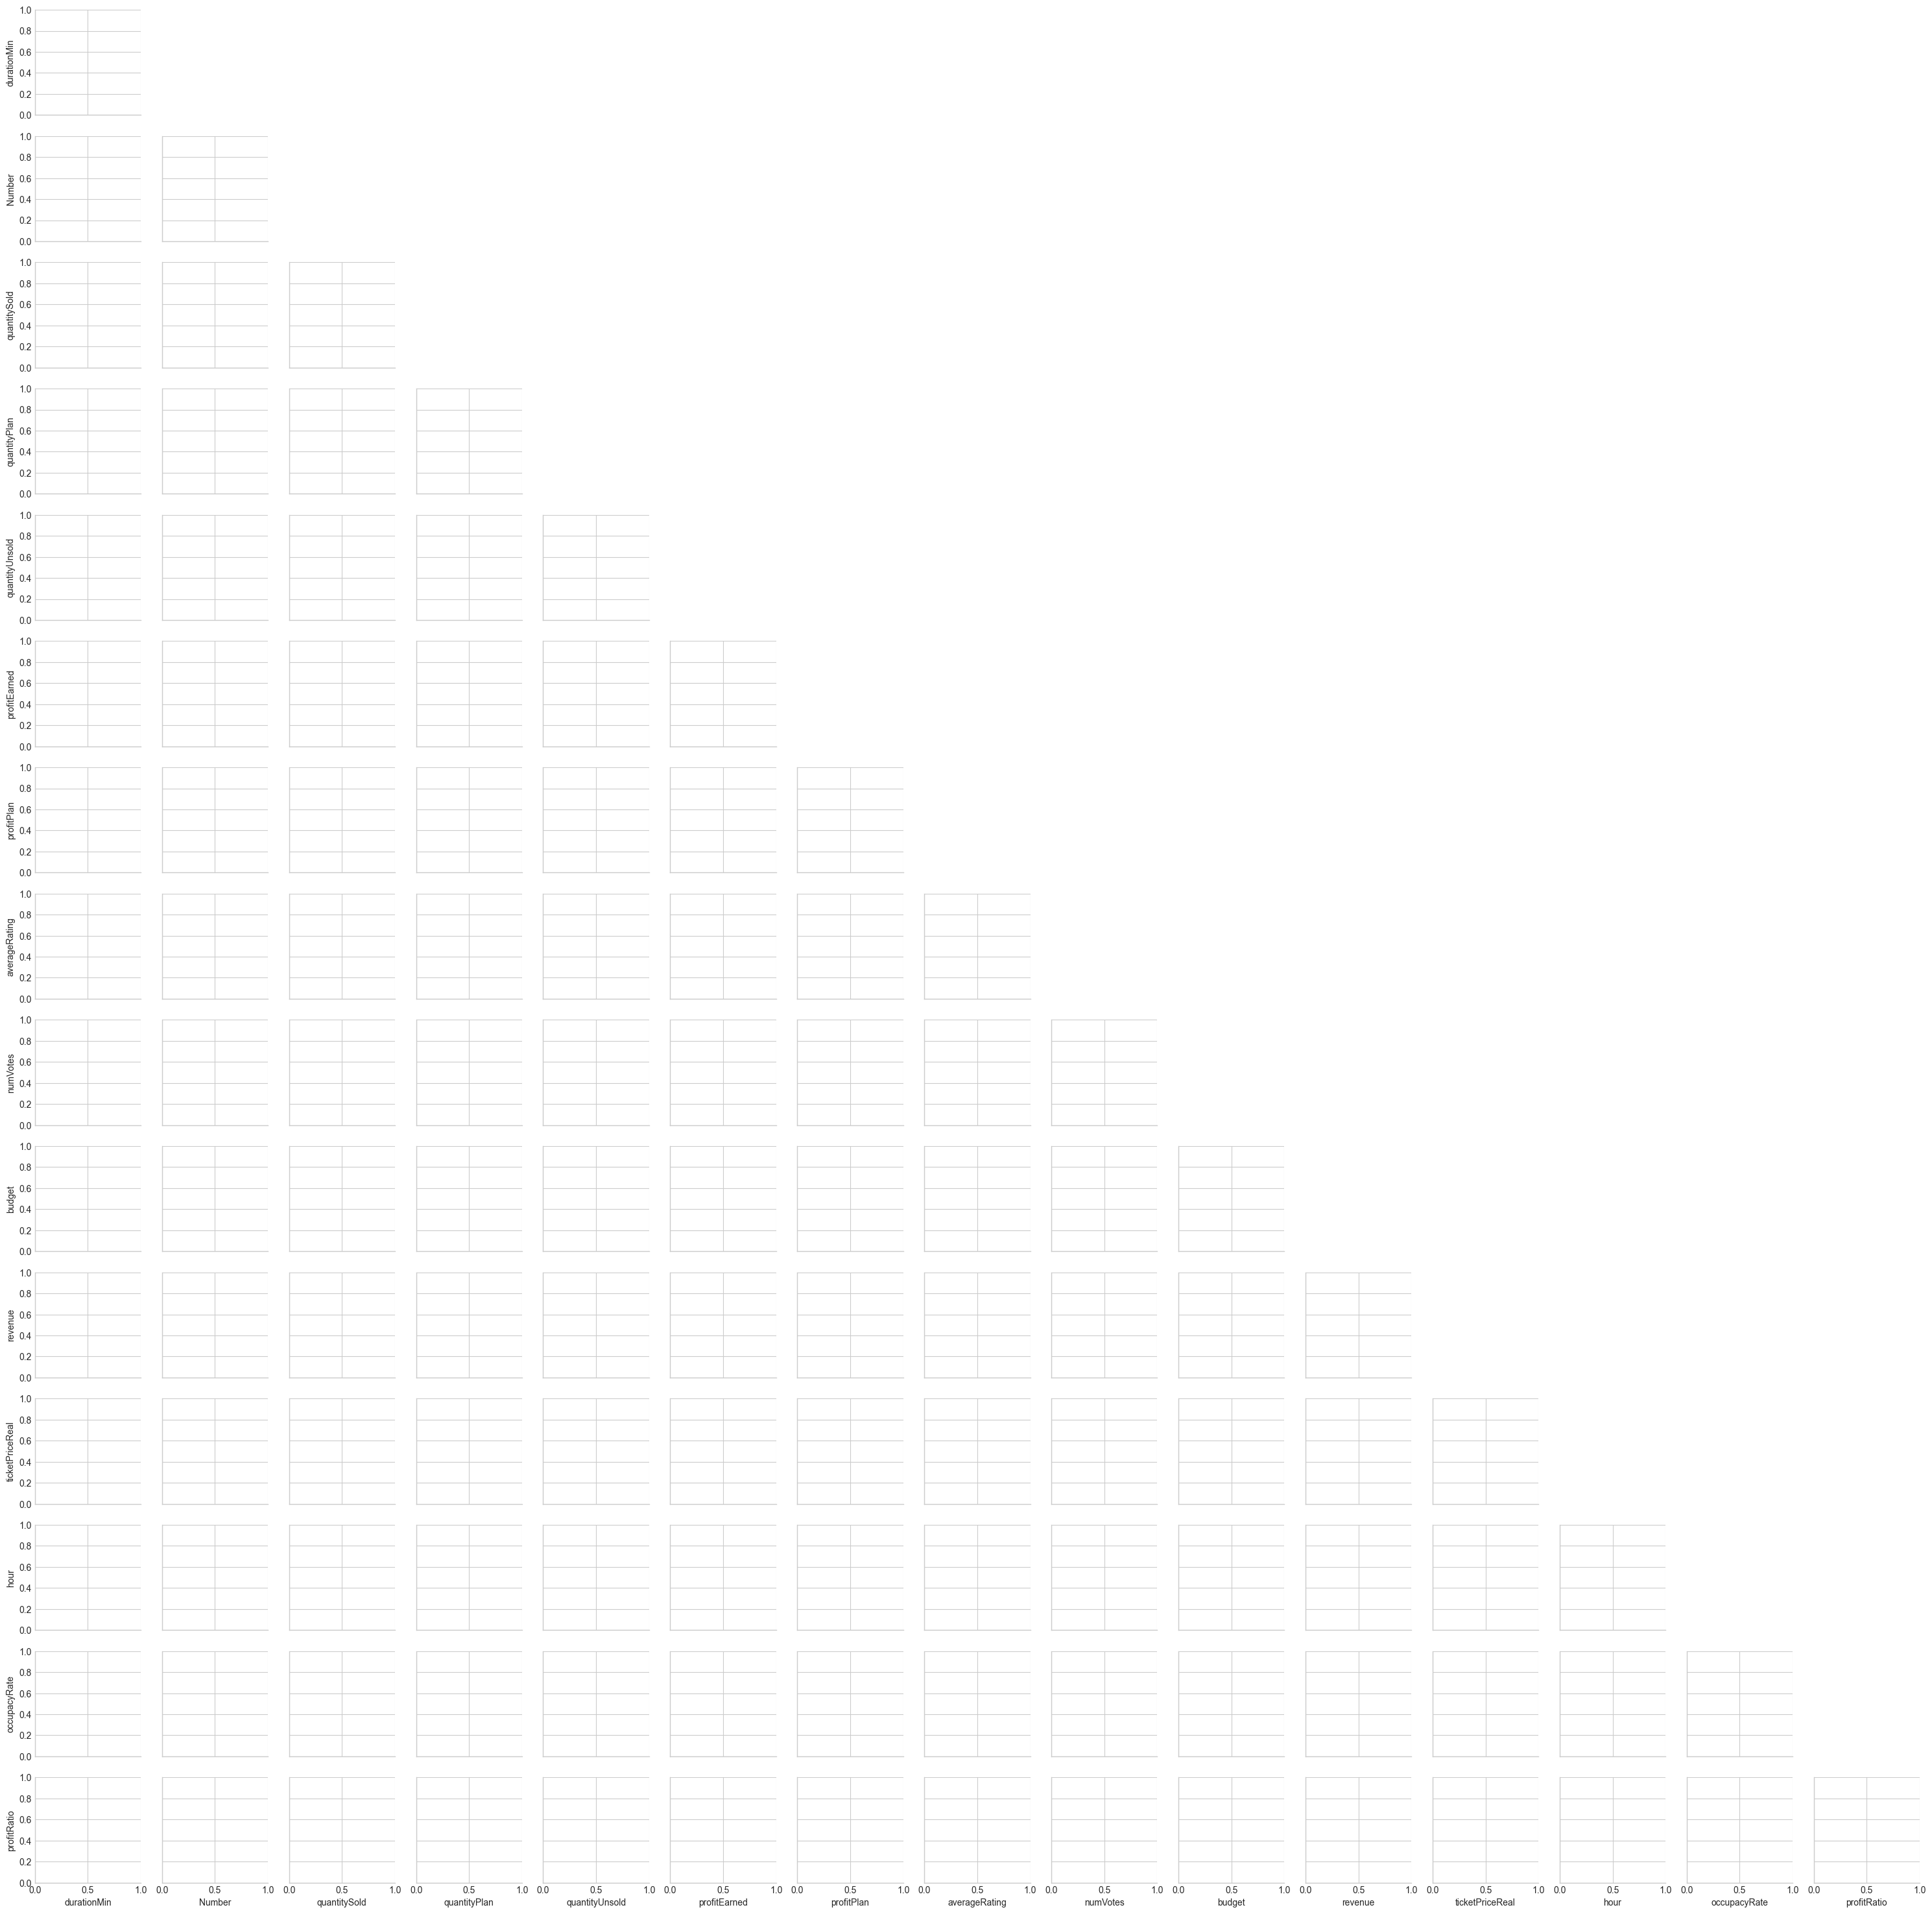

In [114]:
sns.pairplot(df[num_cols].sample(500), corner=True)
plt.show()

кореляційна матриця

In [115]:
corr = df_eda[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1)
plt.title("Кореляційна матриця (numeric)")
plt.show()

NameError: name 'df_eda' is not defined

In [116]:
# до видалення колонок
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_eda[num_cols].drop(columns=['success_index'])
X = sm.add_constant(X)

vif = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif.sort_values('VIF', ascending=False))


NameError: name 'df_eda' is not defined

In [118]:
df['Target'] = np.nan
df[['Cinema', 'Auditorium', 'week']]
for c in df['Cinema'].unique():
    for a in df['Auditorium'].unique():
        for d  in df['week'].unique():
            df.loc[(df['Cinema']==c)&(df['Auditorium']==a)&(df['week']==d), 'Target'] = df.loc[(df['Cinema']==c)&(df['Auditorium']==a)&(df['week']==d), 'occupacyRate'].quantile()
            

KeyboardInterrupt: 

/var/folders/bt/_x0h2pb92g55h0wvnfmyf_900000gp/T/ipykernel_29787/3555280287.py:16: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['Date'] = pd.to_datetime(df['Date'])


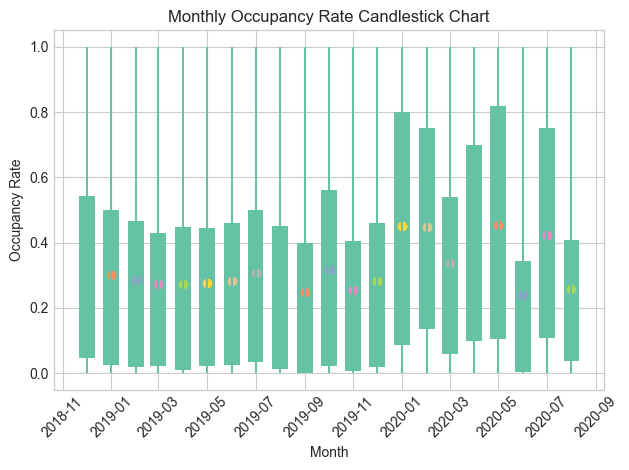

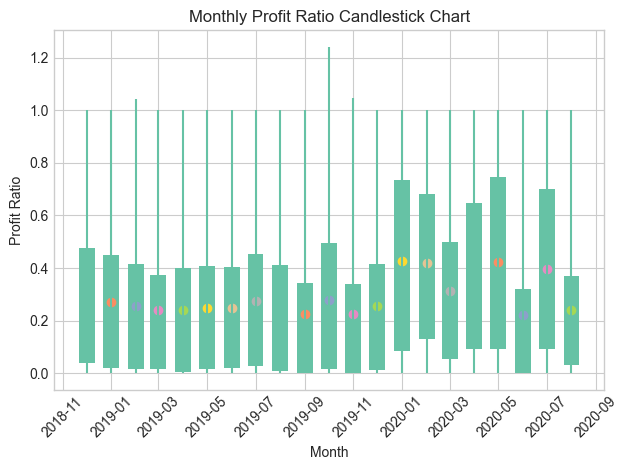

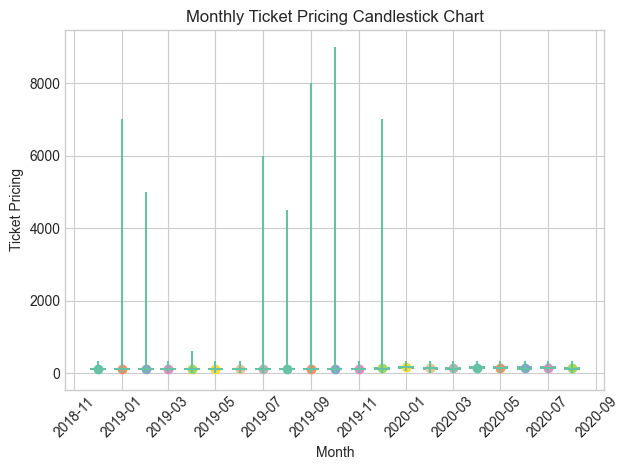

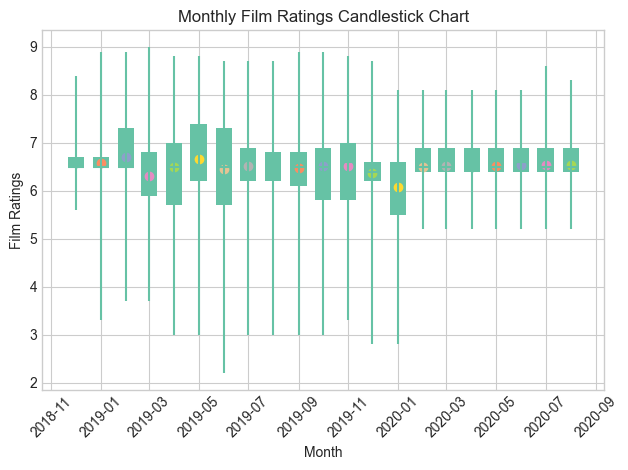

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

# Ensure df is loaded
try:
    df
except NameError:
    try:
        df = pd.read_csv('cinema_data.csv')  # adjust the path if needed
    except FileNotFoundError:
        raise FileNotFoundError("DataFrame 'df' not found; please load your data into 'df' or provide 'cinema_data.csv'")

# Parse dates and add YearMonth
df['Date'] = pd.to_datetime(df['Date'])
df['YearMonth'] = df['Date'].dt.to_period('M').dt.to_timestamp()

# Define metrics and their column names
metrics = {
    'Occupancy Rate': 'occupacyRate',
    'Profit Ratio': 'profitRatio',
    'Ticket Pricing': 'ticketPriceReal',
    'Film Ratings': 'averageRating'
}

# Compute monthly statistics
monthly_stats = {}
for name, col in metrics.items():
    stats = df.groupby('YearMonth')[col].agg(
        min='min',
        q25=lambda x: x.quantile(0.25),
        median='median',
        mean='mean',
        q75=lambda x: x.quantile(0.75),
        max='max'
    )
    monthly_stats[name] = stats

# Plot candlestick-style charts
for name, stats in monthly_stats.items():
    fig, ax = plt.subplots()
    dates = stats.index
    date_nums = mdates.date2num(dates)
    box_width = 20  # days

    # Whiskers
    ax.vlines(date_nums, stats['min'], stats['max'])

    # Boxes, medians, and means
    for i, date in enumerate(date_nums):
        q1 = stats['q25'].iloc[i]
        q3 = stats['q75'].iloc[i]
        med = stats['median'].iloc[i]
        mean = stats['mean'].iloc[i]

        # Box
        rect = Rectangle((date - box_width/2, q1), box_width, q3 - q1)
        ax.add_patch(rect)

        # Median line
        ax.hlines(med, date - box_width/2, date + box_width/2)

        # Mean point
        ax.scatter(date, mean)

    # Format x-axis
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    ax.set_title(f'Monthly {name} Candlestick Chart')
    ax.set_xlabel('Month')
    ax.set_ylabel(name)
    plt.tight_layout()
    plt.show()


In [176]:
def filter_by_sigma(df, col, n_sigma=3):
    """
    Keep only rows where col is within mean ± n_sigma * std.
    """
    mu    = df[col].mean()
    sigma = df[col].std()
    lower = mu - n_sigma * sigma
    upper = mu + n_sigma * sigma
    print(f"Filtering {col}: mean={mu:.2f}, σ={sigma:.2f}, keep ∈ [{lower:.2f}, {upper:.2f}]")
    return df[(df[col] >= lower) & (df[col] <= upper)]

# Example: replace your static filter
# df = df[df['ticketPriceReal'] <= 500]
df = filter_by_sigma(df, 'ticketPriceReal', n_sigma=3)

Filtering ticketPriceReal: mean=123.18, σ=74.26, keep ∈ [-99.61, 345.96]


In [177]:
df['ticketPriceReal'].max()

345.9230769230769

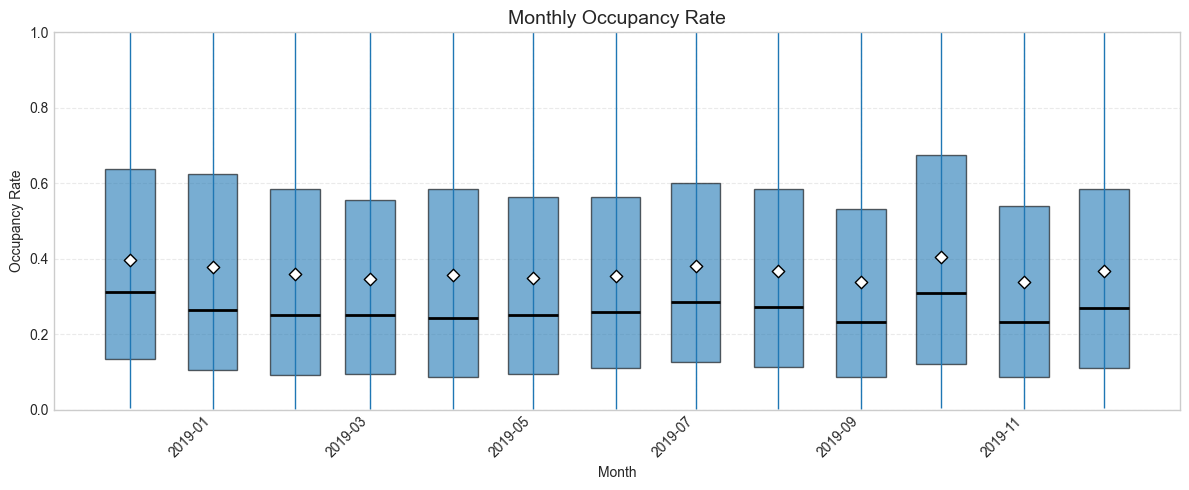

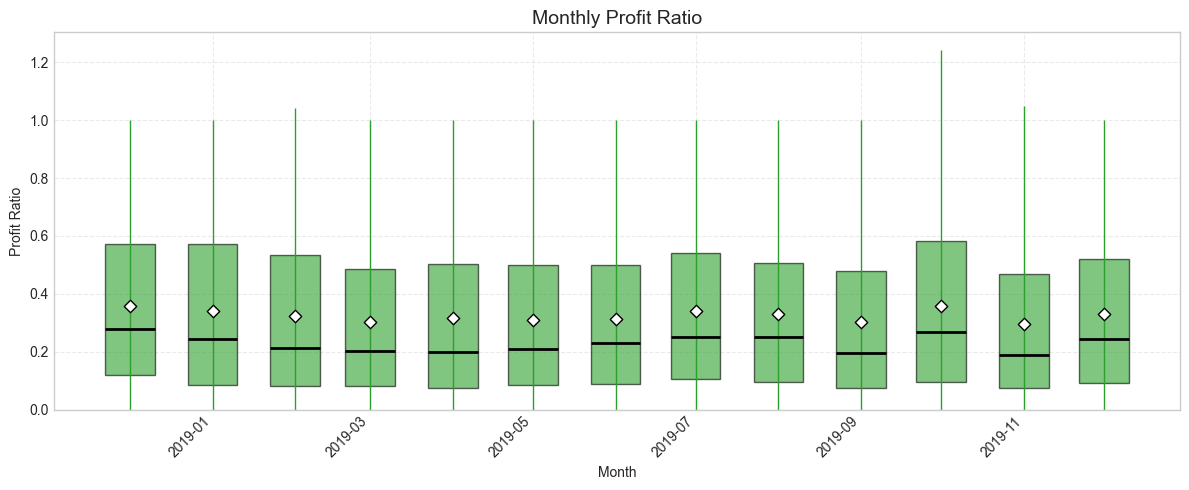

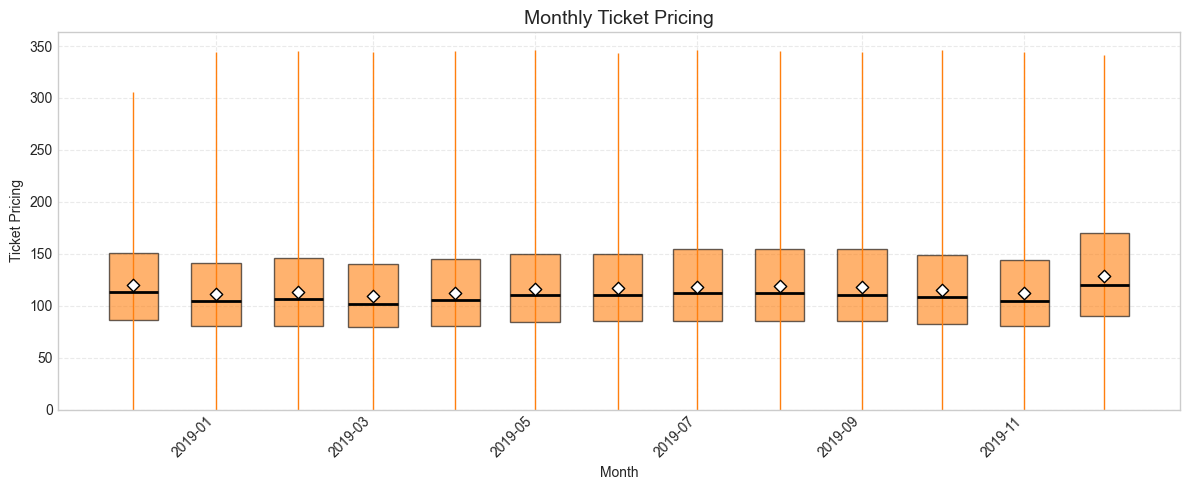

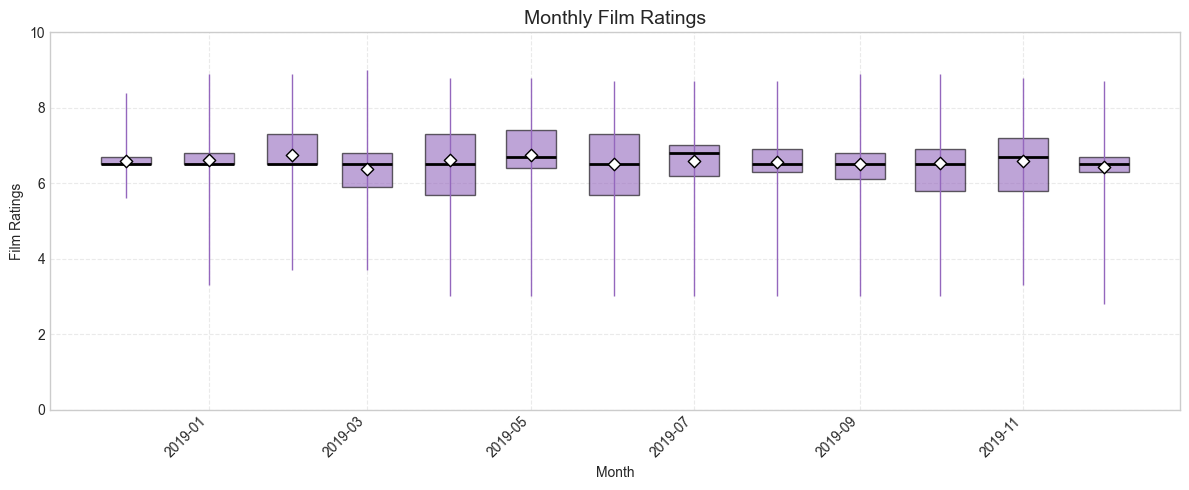

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- prepare your df ---
# df = pd.read_csv('cinema_data.csv')           # if you need to reload
# df['Date'] = pd.to_datetime(df['Date'])
df = df[df["Date"].apply(str) != "NaT"]
df = df[df["Date"].apply(str).apply(lambda x: int(x.split("-")[0])) < 2020]
df['YearMonth'] = df['Date'].dt.to_period('M').dt.to_timestamp()

# --- define each metric’s settings ---
metrics = {
    'Occupancy Rate': {
        'col': 'occupacyRate',
        'ylim': (0.0, 1.0),
        'color': '#1f77b4'
    },
    'Profit Ratio': {
        'col': 'profitRatio',
        'ylim': None,                   # dynamic
        'color': '#2ca02c'
    },
    'Ticket Pricing': {
        'col': 'ticketPriceReal',
        'ylim': None,                   # dynamic
        'color': '#ff7f0e'
    },
    'Film Ratings': {
        'col': 'averageRating',
        'ylim': (0.0, 10.0),
        'color': '#9467bd'
    }
}

# --- helper to compute monthly aggregates ---
def monthly_stats(df, col):
    return df.groupby('YearMonth')[col].agg(
        min='min',
        q25=lambda x: x.quantile(0.25),
        median='median',
        mean='mean',
        q75=lambda x: x.quantile(0.75),
        max='max'
    )

# --- loop and plot ---
for title, props in metrics.items():
    col   = props['col']
    color = props['color']
    ylim  = props['ylim']
    
    stats = monthly_stats(df, col)
    dates = stats.index
    date_nums = mdates.date2num(dates)
    
    # compute a box width ~60% of the month spacing
    if len(date_nums) > 1:
        width = (date_nums[1] - date_nums[0]) * 0.6
    else:
        width = 15
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # draw whiskers
    ax.vlines(date_nums, stats['min'], stats['max'], color=color, linewidth=1)
    
    # draw boxes, median line and mean marker
    for i, dn in enumerate(date_nums):
        q1 = stats['q25'].iloc[i]
        q3 = stats['q75'].iloc[i]
        med = stats['median'].iloc[i]
        mean = stats['mean'].iloc[i]
        
        # box
        rect = plt.Rectangle(
            (dn - width/2, q1),
            width, q3 - q1,
            facecolor=color,
            edgecolor='black',
            alpha=0.6
        )
        ax.add_patch(rect)
        
        # median
        ax.hlines(med, dn - width/2, dn + width/2, color='black', linewidth=2)
        # mean
        ax.scatter([dn], [mean],
                   marker='D', edgecolor='black',
                   facecolor='white', zorder=3, s=40)
    
    # formatting
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45, ha='right')
    ax.set_title(f'Monthly {title}', fontsize=14)
    ax.set_xlabel('Month')
    ax.set_ylabel(title)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # set y-limits
    if ylim:
        ax.set_ylim(*ylim)
    else:
        # pad dynamic limits by 5%
        ymin, ymax = stats['min'].min(), stats['max'].max()
        padding = (ymax - ymin) * 0.05
        ax.set_ylim(max(0, ymin - padding), ymax + padding)
    
    plt.tight_layout()
    plt.show()


In [ ]:
df['Month_str'] = df["Date"].apply(str).apply(lambda x : x.split("-")[1])
# df = df[df["Month_str"] == df['Month'].apply(str)]
df[['Month',"Month_str","Date"]]

In [ ]:
df1 = df[df["Month_str"] == df['Month'].apply(str)]
df1[['Month',"Month_str","Date"]]

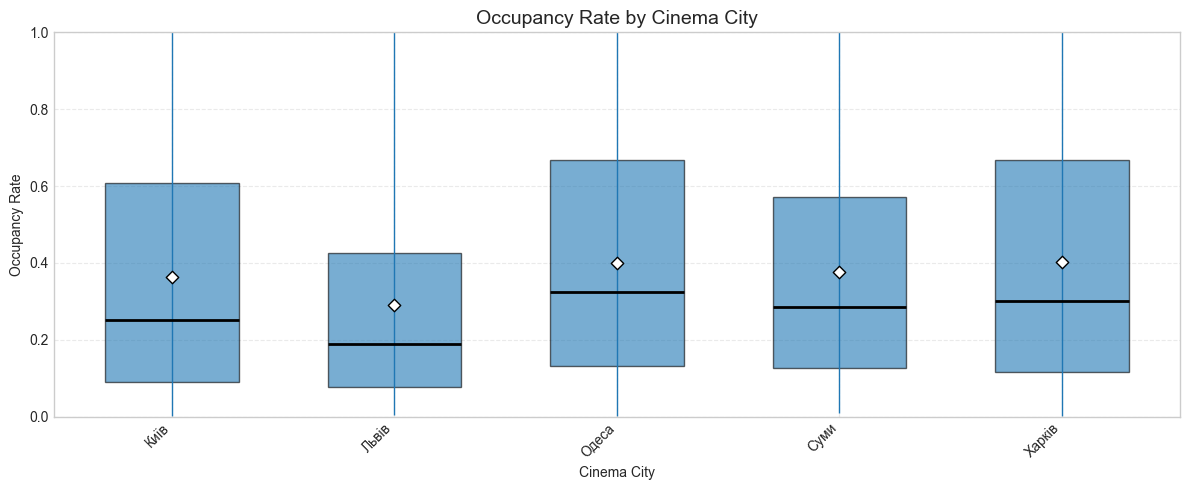

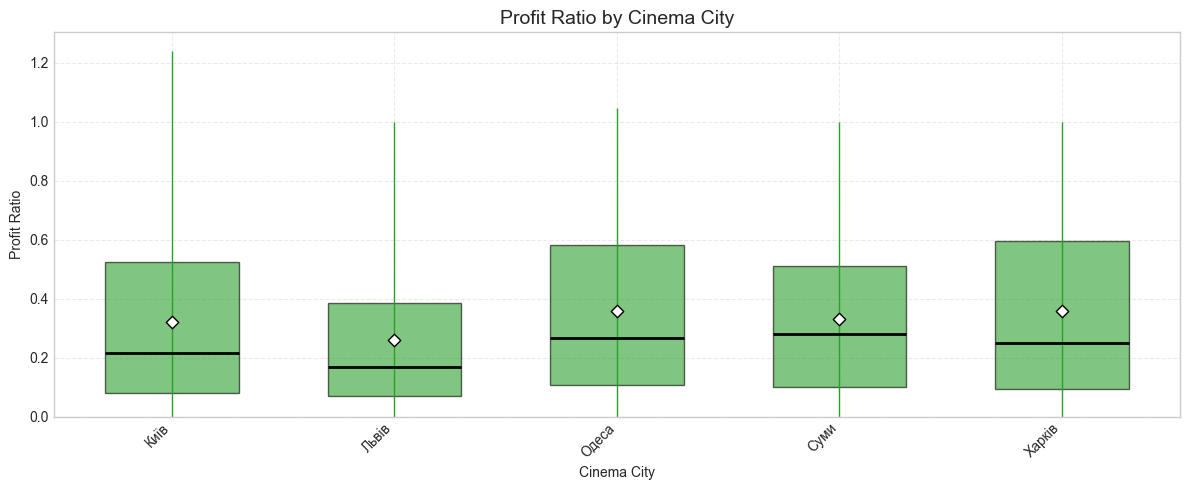

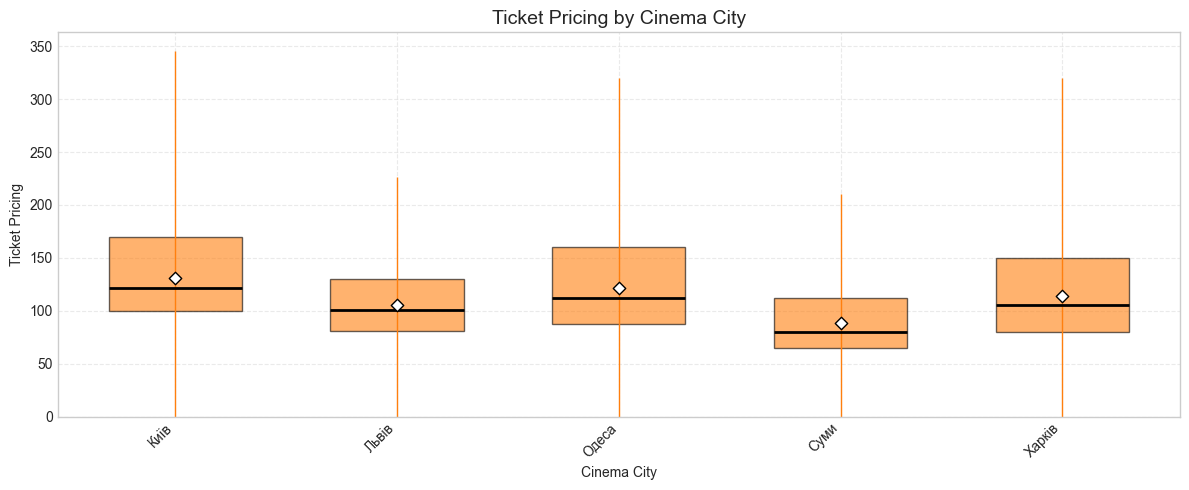

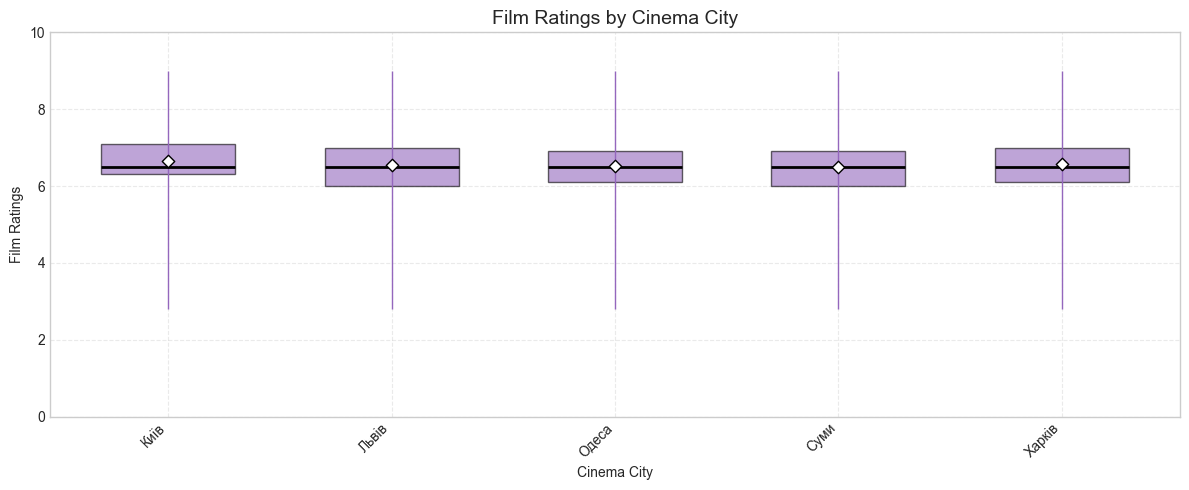

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- assume df is already loaded & filtered as before ---
# drop any rows where Date is NaT or year ≥ 2020
df = df[df["Date"].notna() & (df["Date"].dt.year < 2020)]

# --- metrics dict unchanged ---
metrics = {
    'Occupancy Rate': {
        'col': 'occupacyRate',
        'ylim': (0.0, 1.0),
        'color': '#1f77b4'
    },
    'Profit Ratio': {
        'col': 'profitRatio',
        'ylim': None,
        'color': '#2ca02c'
    },
    'Ticket Pricing': {
        'col': 'ticketPriceReal',
        'ylim': None,
        'color': '#ff7f0e'
    },
    'Film Ratings': {
        'col': 'averageRating',
        'ylim': (0.0, 10.0),
        'color': '#9467bd'
    }
}

# --- helper: aggregate by cinemaCity instead of by month ---
def city_stats(df, col):
    return df.groupby('cinemaCity')[col].agg(
        min='min',
        q25=lambda x: x.quantile(0.25),
        median='median',
        mean='mean',
        q75=lambda x: x.quantile(0.75),
        max='max'
    )

# --- loop and plot for each metric ---
for title, props in metrics.items():
    col   = props['col']
    color = props['color']
    ylim  = props['ylim']
    
    stats = city_stats(df, col)
    cities = stats.index.tolist()
    positions = np.arange(len(cities))  # x positions
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # draw whiskers
    ax.vlines(positions, stats['min'], stats['max'], color=color, linewidth=1)
    
    # draw boxes, median line and mean marker
    box_width = 0.6  # fixed fraction of 1.0 spacing
    for i, pos in enumerate(positions):
        q1 = stats['q25'].iloc[i]
        q3 = stats['q75'].iloc[i]
        med = stats['median'].iloc[i]
        mean = stats['mean'].iloc[i]
        
        # box
        rect = plt.Rectangle(
            (pos - box_width/2, q1),
            box_width, q3 - q1,
            facecolor=color,
            edgecolor='black',
            alpha=0.6
        )
        ax.add_patch(rect)
        
        # median line
        ax.hlines(med, pos - box_width/2, pos + box_width/2, color='black', linewidth=2)
        # mean marker
        ax.scatter([pos], [mean],
                   marker='D', edgecolor='black',
                   facecolor='white', zorder=3, s=40)
    
    # formatting
    ax.set_xticks(positions)
    ax.set_xticklabels(cities, rotation=45, ha='right')
    ax.set_title(f'{title} by Cinema City', fontsize=14)
    ax.set_xlabel('Cinema City')
    ax.set_ylabel(title)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # set y-limits
    if ylim:
        ax.set_ylim(*ylim)
    else:
        ymin, ymax = stats['min'].min(), stats['max'].max()
        padding = (ymax - ymin) * 0.05
        ax.set_ylim(max(0, ymin - padding), ymax + padding)
    
    plt.tight_layout()
    plt.show()
